In [1]:
import yfinance as yf
ticker = yf.Ticker('AAPL')

import datetime

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from optionanalytics.data.yahoo import fetch_option_chain
from optionanalytics.cleaning.filters import clean_option_chain
from optionanalytics.cleaning.arbitrage import filter_price_bound_violations
from optionanalytics.models.market import MarketData
from optionanalytics.volatility.smile import build_smile

ticker = "AAPL"
expiry = "2026-08-21"

valuation_date = datetime.date(2026, 7, 18)

market_data = MarketData(
    spot=333.74,
    risk_free_rate=0.0418,
    volatility=0.20,      # Placeholder
)

In [2]:
chain = fetch_option_chain(ticker, expiry)

clean_chain = clean_option_chain(chain)

clean_chain = filter_price_bound_violations(
    clean_chain,
    market_data,
    valuation_date,
)

smile = build_smile(
    clean_chain,
    market_data,
    valuation_date,
)

Text(0, 0.5, 'Implied Volatility')

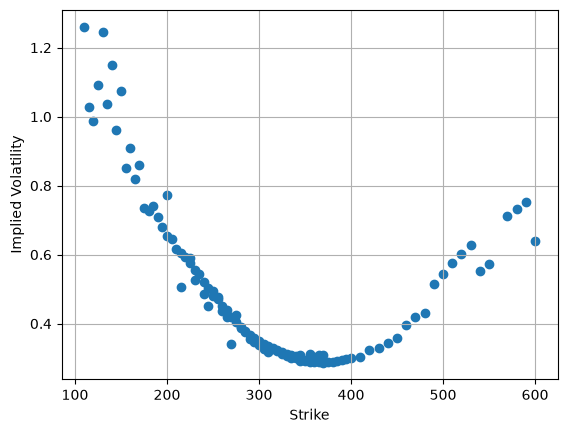

In [3]:
strikes = [p.strike for p in smile.points]
ivs = [p.implied_volatility for p in smile.points]

plt.scatter(strikes, ivs, label="Market Quotes")
plt.grid(True)
plt.xlabel("Strike")
plt.ylabel("Implied Volatility")

In [4]:
from optionanalytics.volatility.interpolation import interpolate_smile
from optionanalytics.utils.dates import year_fraction
from optionanalytics.pricing.black_scholes import black_scholes

from optionanalytics.models.density import Density, DensityPoint
from optionanalytics.models.volatility import VolatilitySmile
from optionanalytics.models.market import MarketData
from optionanalytics.models.enums import InterpolationMethod, OptionType
from optionanalytics.pricing.black_scholes import EuropeanOption

maturity = year_fraction(
    smile.expiry,
    valuation_date,
)

#### CUBIC_SPLINE INTERPOLATION

In [ ]:
iv_function = interpolate_smile(
    smile,
    InterpolationMethod.CUBIC_SPLINE,
)

In [5]:
strikes = [p.strike for p in smile.points]

K = np.linspace(
    min(strikes),
    max(strikes),
    300,
)

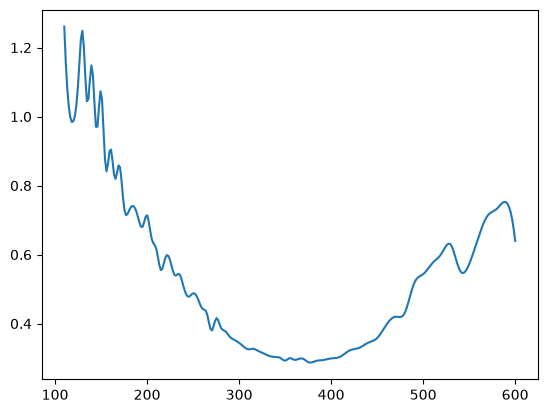

In [6]:
plt.plot(K, iv_function(K))

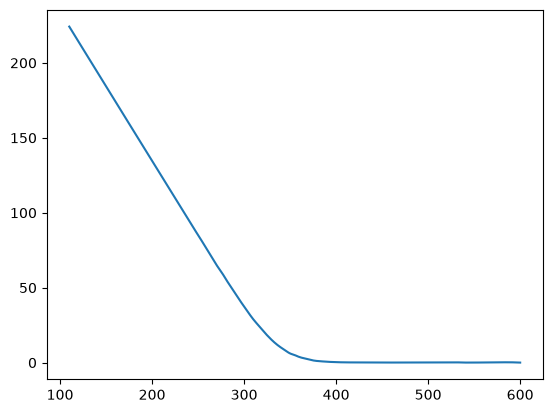

In [7]:
from optionanalytics.density.risk_neutral import _price_from_smile
C = np.array([
    _price_from_smile(
        k,
        iv_function,
        maturity,
        market_data,
    )
    for k in K
])
plt.plot(K, C)

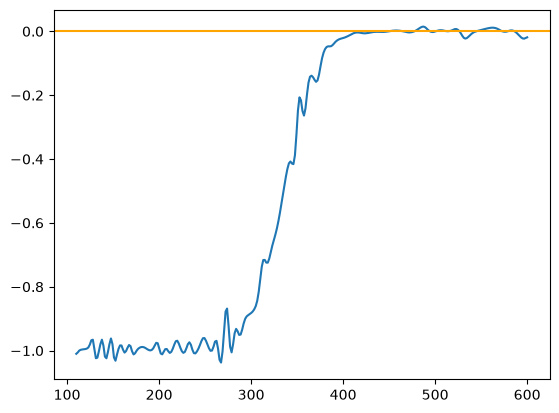

In [8]:
first = np.gradient(C, K)

plt.plot(K, first)
plt.axhline(0, color='orange')

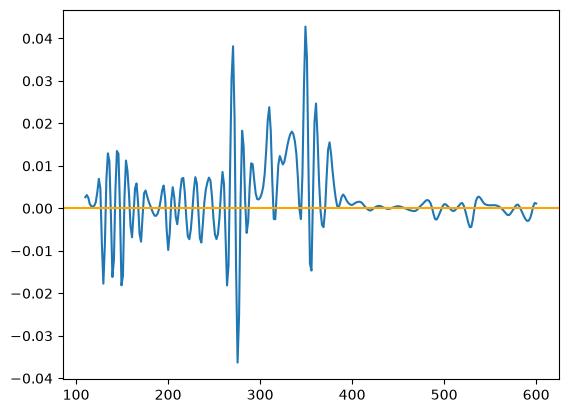

In [9]:
second = np.gradient(first, K)

plt.plot(K, second)
plt.axhline(0, color='orange')

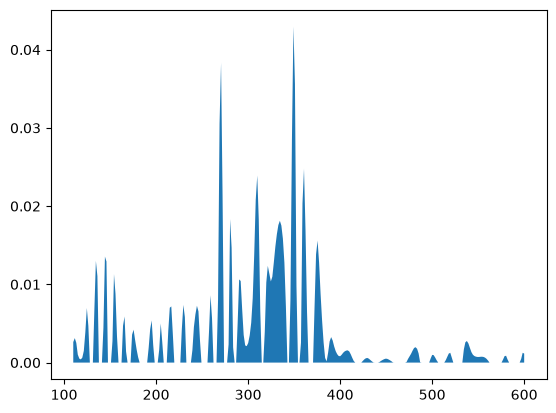

In [10]:
pdf = np.exp(
    market_data.risk_free_rate * maturity
) * second

pdf = np.maximum(pdf, 0)
plt.fill_between(K, pdf)

In [11]:
import numpy as np
area = np.trapezoid(pdf, K)

print(area) # Expected 1.000

1.7348360873269106


#### AKIMA INTERPOLATION

In [12]:
iv_function = interpolate_smile(
    smile,
    InterpolationMethod.AKIMA,
)

In [13]:
strikes = [p.strike for p in smile.points]

K = np.linspace(
    min(strikes),
    max(strikes),
    300,
)

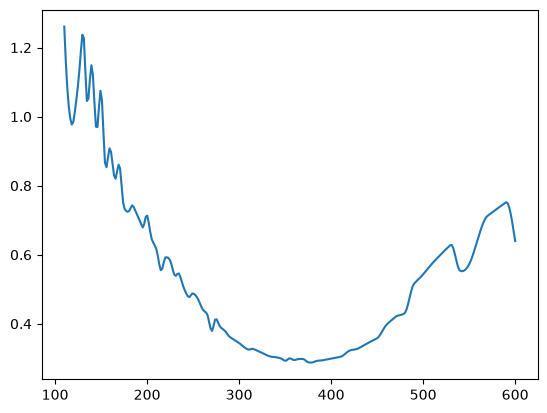

In [14]:
plt.plot(K, iv_function(K))

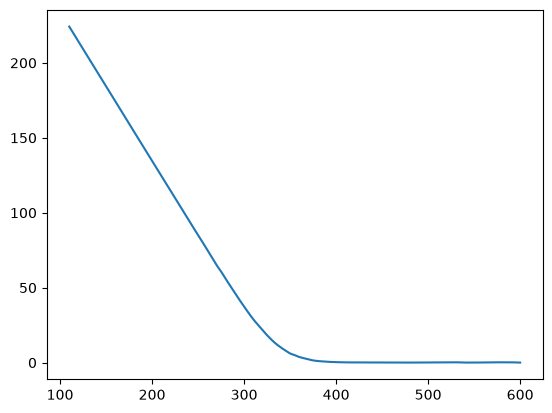

In [15]:
from optionanalytics.density.risk_neutral import _price_from_smile
C = np.array([
    _price_from_smile(
        k,
        iv_function,
        maturity,
        market_data,
    )
    for k in K
])
plt.plot(K, C)

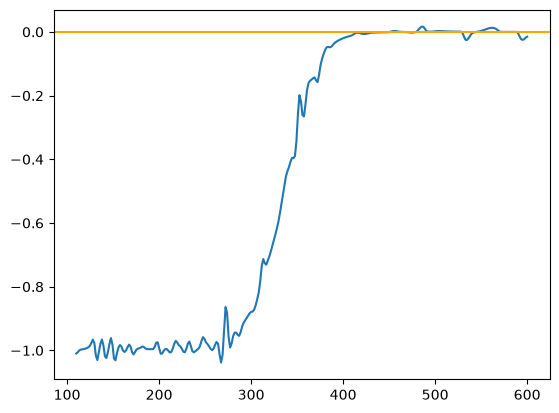

In [16]:
first = np.gradient(C, K)

plt.plot(K, first)
plt.axhline(0, color='orange')

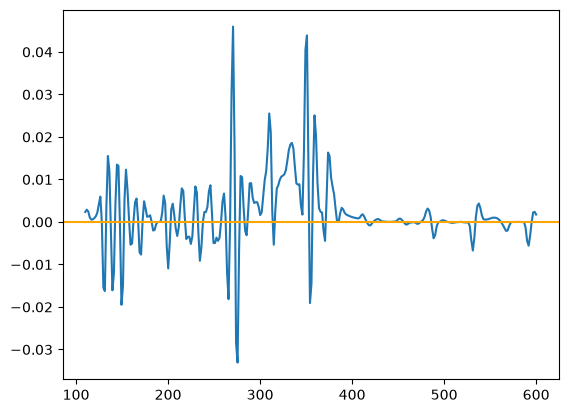

In [17]:
second = np.gradient(first, K)

plt.plot(K, second)
plt.axhline(0, color='orange')

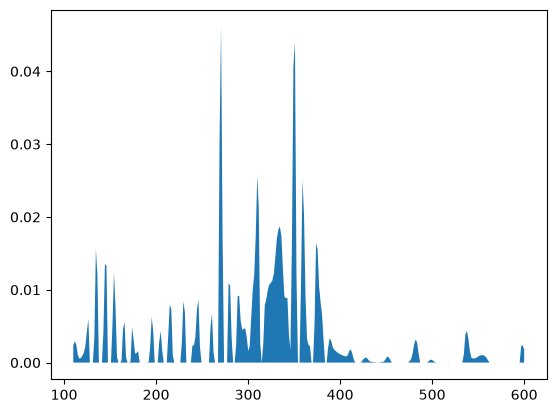

In [18]:
pdf = np.exp(
    market_data.risk_free_rate * maturity
) * second

pdf = np.maximum(pdf, 0)
plt.fill_between(K, pdf)

In [19]:
import numpy as np
area = np.trapezoid(pdf, K)

print(area) # Expected 1.000

1.6839188444150879


#### Conclusion
None of the interpolation methods evaluated (PCHIP, Akima, or Cubic Spline) produced a stable risk-neutral density under numerical differentiation.

Breeden–Litzenberger formula depends on the second derivative of the option price. Small differences in curvature are therefore greatly amplified during density recovery.

This motivates replacing generic interpolation schemes with arbitrage-aware parameterizations, such as SVI (Stochastic Volatility Inspired), which are specifically designed to produce smooth, stable, and arbitrage-free implied volatility surfaces suitable for density extraction.